In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/RecPad')

import numpy as np
import pandas as pd
import utils.plot_dashes as plot_dashes

from conf.processing import DataProcessing
from utils import genetic_algorithm as gen_alg
from models import ann_models, kernel_method, tree_based_ensemble as tree_based

# pd.set_option('display.float_format', '{:.6f}'.format)

Melbin

In [3]:
melbin = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets/melbmin.txt', sep='\t', decimal='.')

In [44]:
melbin

,y
0,20.7
1,17.9
2,18.8
3,14.6
4,15.8
...,...
3645,14.0
3646,13.6
3647,13.5
3648,15.7


In [62]:
stats = pd.DataFrame({
    "Series": ["Melbin"],
    "Count": [melbin["y"].count()],
    "Mean": [melbin["y"].mean()],
    "STD": [melbin["y"].std()],
    "Min": [melbin["y"].min()],
    "Max": [melbin["y"].max()],
    "CV": [melbin["y"].std() / melbin["y"].mean()] #  Coeficiente de Variação
})

stats

,Series,Count,Mean,STD,Min,Max,CV
0,Melbin,3650,11.177151,4.073492,-0.8,26.3,0.364448


Airlines

In [27]:
'''
    Info Base - melbmin.txt

    10 Anos des temperatura mínima diária em Melbourne, Austrália.
    De 1980-12-31 à 1990-12-31

'''
airlines = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets/airlines.txt', sep='\t', decimal='.')

In [28]:
airlines

,y
0,112
1,118
2,132
3,129
4,121
...,...
139,606
140,508
141,461
142,390


In [61]:
stats = pd.DataFrame({
    "Series": ["Airlines"],
    "Count": [airlines["y"].count()],
    "Mean": [airlines["y"].mean()],
    "STD": [airlines["y"].std()],
    "Min": [airlines["y"].min()],
    "Max": [airlines["y"].max()],
    "CV": [airlines["y"].std() / airlines["y"].mean()] #  Coeficiente de Variação
})

stats

,Series,Count,Mean,STD,Min,Max,CV
0,Airlines,144,280.298611,119.966317,104,622,0.427995


coloradoRiver

In [34]:
colorado = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets/coloradoRiver.txt', sep='\t', decimal='.')

In [35]:
colorado

,y
0,0.46
1,0.53
2,1.24
3,1.48
4,3.69
...,...
739,1.23
740,1.14
741,0.77
742,0.82


In [60]:
stats = pd.DataFrame({
    "Series": ["ColoradoRiver"],
    "Count": [colorado["y"].count()],
    "Mean": [colorado["y"].mean()],
    "STD": [colorado["y"].std()],
    "Min": [colorado["y"].min()],
    "Max": [colorado["y"].max()],
    "CV": [colorado["y"].std() / colorado["y"].mean()] #  Coeficiente de Variação
})

stats

,Series,Count,Mean,STD,Min,Max,CV
0,ColoradoRiver,744,1.237567,1.376469,0.07,9.81,1.112238


Lynx

In [40]:
lynx = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets/lynx.txt', sep='\t', decimal='.')

In [41]:
lynx

,y
0,269
1,321
2,585
3,871
4,1475
...,...
109,662
110,1000
111,1590
112,2657


In [59]:
stats = pd.DataFrame({
    "Series": ["Lynx"],
    "Count": [lynx["y"].count()],
    "Mean": [lynx["y"].mean()],
    "STD": [lynx["y"].std()],
    "Min": [lynx["y"].min()],
    "Max": [lynx["y"].max()],
    "CV": [lynx["y"].std() / lynx["y"].mean()] #  Coeficiente de Variação
})

stats

,Series,Count,Mean,STD,Min,Max,CV
0,Lynx,114,1538.017544,1585.843914,39,6991,1.031096


Previsões

In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets/coloradoRiver.txt', sep='\t', decimal='.')

In [8]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets/lynx.txt', sep='\t', decimal='.')

In [11]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets/airlines.txt', sep='\t', decimal='.')

In [14]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Forecast/Datasets/melbmin.txt', sep='\t', decimal='.')

In [15]:

raw_data = DataProcessing(dataset, n_lags=5)
prep_data = raw_data.prepare_data()

mlp = ann_models.MLP()
results_MLP = mlp.train(prep_data)
MLP_forecast_v = np.array(results_MLP['pred_valid'])
MLP_forecast = np.array(results_MLP['pred_test_denom'])

scn = ann_models.GridSCN()
results_SCN = scn.train(prep_data)
SCN_forecast_v = np.array(results_SCN['pred_valid'])
SCN_forecast = np.array(results_SCN['pred_test'])

elm = ann_models.GridELM()
results_ELM = elm.train(prep_data)
ELM_forecast_v = np.array(results_ELM['pred_valid'])
ELM_forecast = np.array(results_ELM['pred_test_denom'])

svr = kernel_method.SVM()
results_SVR = svr.train(prep_data)
SVR_forecast_v = np.array(results_SVR['pred_valid'])
SVR_forecast = np.array(results_SVR['pred_test'])

rf = tree_based.RF()
results_RF = rf.train(prep_data)
RF_forecast_v = np.array(results_RF['pred_valid'])
RF_forecast = np.array(results_RF['pred_test'])

gb = tree_based.GBoosting()
results_GB = gb.train(prep_data)
GB_forecast_v = np.array(results_GB['pred_valid'])
GB_forecast = np.array(results_GB['pred_test'])

P_v = np.column_stack(
    (
        MLP_forecast_v.copy(), 
        SCN_forecast_v.copy(),
        ELM_forecast_v.copy(), 
        SVR_forecast_v.copy(), 
        RF_forecast_v.copy(), 
        GB_forecast_v.copy()
    )
)

P = np.column_stack(
    (
        MLP_forecast.copy(), 
        SCN_forecast.copy(),
        ELM_forecast.copy(), 
        SVR_forecast.copy(), 
        RF_forecast.copy(), 
        GB_forecast.copy()
    )
)

ga_runs = []
for x in range(30):
    
    ga = gen_alg.GeneticAlgorithm()
    
    ga_result = ga.execute(P_v, prep_data['target_valid'])

    y_hat = P @ ga_result['best_ind']
    ga_metrics = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat)

    run = {
        'Run': x,

        'MSE': ga_metrics['MSE'],
        'RMSE': ga_metrics['RMSE'],
        'MAE': ga_metrics['MAE'],
        'MAPE': ga_metrics['MAPE'],

        'Weights': ga_result['best_ind'],
        'Fitness': ga_result['best_fitness'],
        'Fitness_Curve': ga_result['fitness_curve']
    }
    ga_runs.append(run)



best = max( 
    ga_runs,
    key=lambda r: r["Fitness"]
)

y_hat_final = P @ best["Weights"]

weights = np.array([1/6]*6)
ensemble_mean = P @ weights

MLP = plot_dashes.get_metrics_error(prep_data['target_test'], MLP_forecast)
SCN = plot_dashes.get_metrics_error(prep_data['target_test'], SCN_forecast)
ELM = plot_dashes.get_metrics_error(prep_data['target_test'], ELM_forecast)
SVR = plot_dashes.get_metrics_error(prep_data['target_test'], SVR_forecast)
RF = plot_dashes.get_metrics_error(prep_data['target_test'], RF_forecast)
GB = plot_dashes.get_metrics_error(prep_data['target_test'], GB_forecast)
EMEAN = plot_dashes.get_metrics_error(prep_data['target_test'], ensemble_mean)
GA = plot_dashes.get_metrics_error(prep_data['target_test'], y_hat_final)


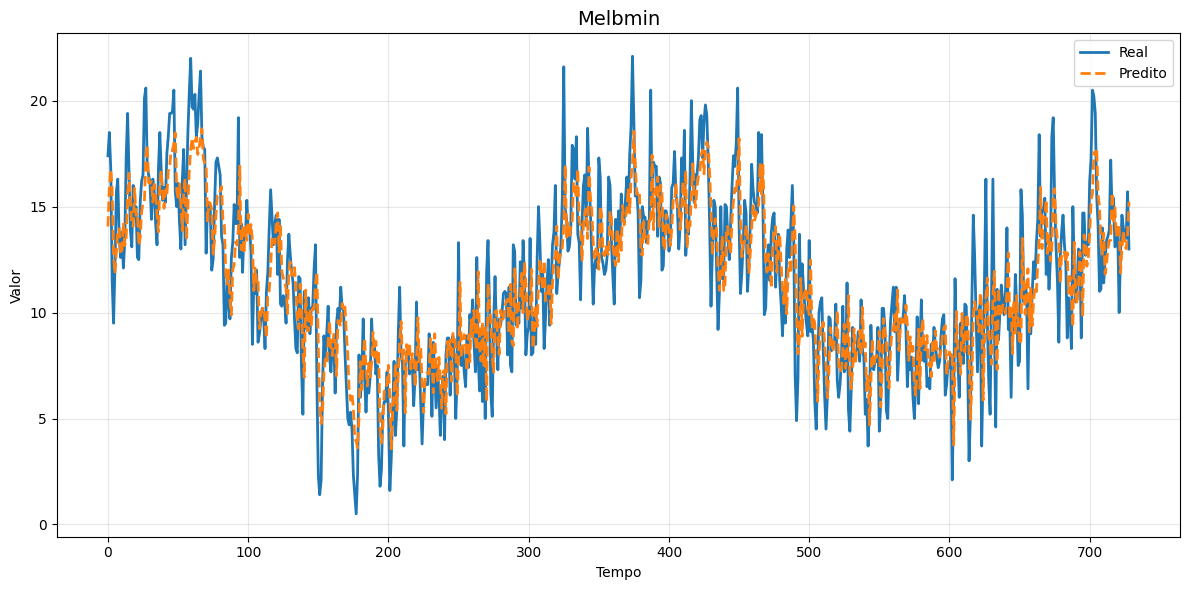

In [16]:
plot_dashes.get_prediction_plot(prep_data['target_test'], y_hat, dataset='Melbmin')


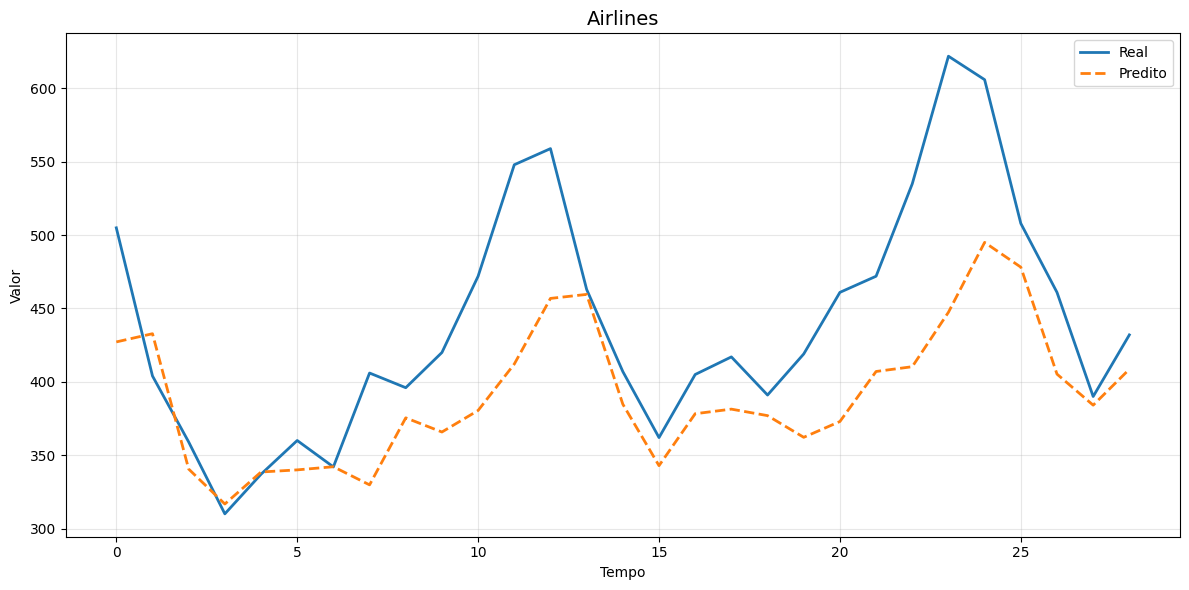

In [13]:
plot_dashes.get_prediction_plot(prep_data['target_test'], y_hat, dataset='Airlines')

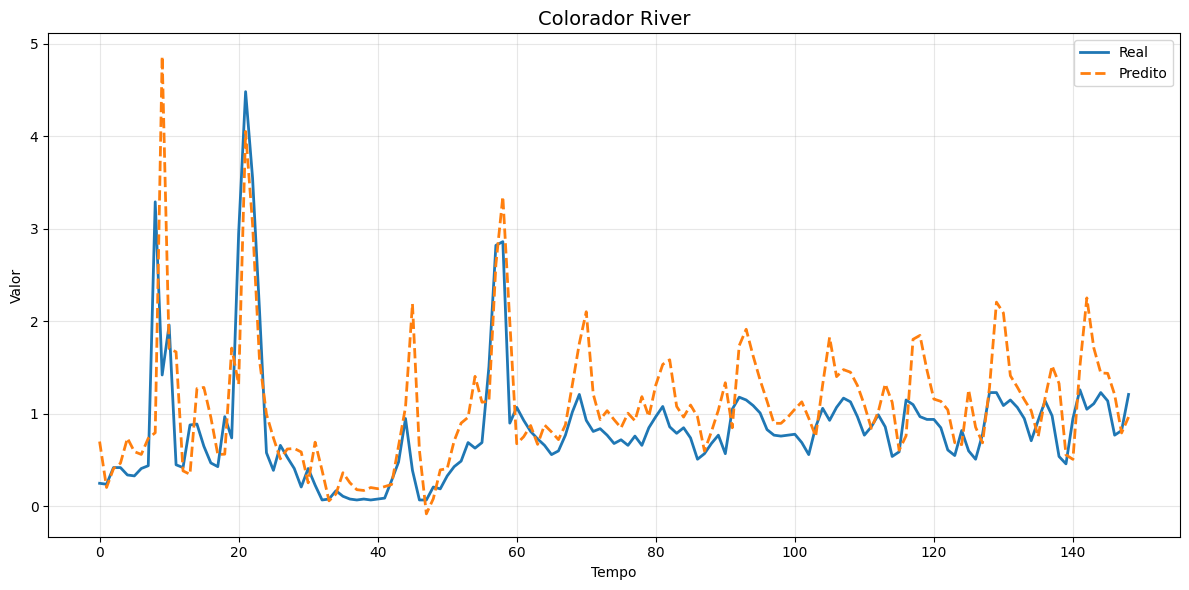

In [7]:
plot_dashes.get_prediction_plot(prep_data['target_test'], y_hat, dataset='Colorador River')

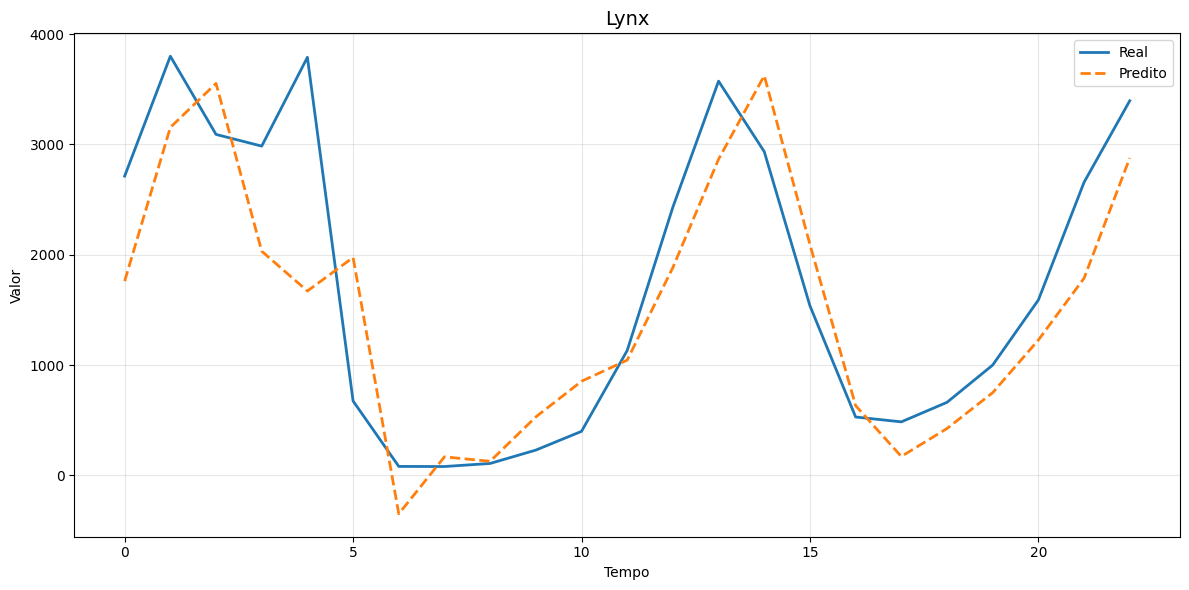

In [10]:
plot_dashes.get_prediction_plot(prep_data['target_test'], y_hat, dataset='Lynx')